# MRCR baseline probe — entropy instability analysis\n\nWindowed entropy statistics → instability score → correlation with retrieval quality.

In [202]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore, pearsonr, spearmanr

PROBE_PATH  = "/c2/jenny/r3/MRCR_outputs/probe_8needle_64-128k_qwen2B.jsonl"
WINDOW      = 16
ENTROPY_KEY = "norm_entropy_trace"   # output token entropy (H over vocab / log vocab_size) # norm_entropy_trace vs attn_entropy_trace
# ENTROPY_KEY = "attn_entropy_trace"

# CTX_LABEL = os.path.splitext(os.path.basename(PROBE_PATH))[0][-7:]
CTX_LABEL = "64-128k_qwen2B"
print(f"context range: {CTX_LABEL}")

context range: 64-128k_qwen2B


In [203]:
records = []
with open(PROBE_PATH) as f:
    for line in f:
        records.append(json.loads(line))
print(f"loaded {len(records)} samples")

loaded 102 samples


In [204]:
def windowed_stats(entropy_trace, window_size=WINDOW):
    """Sliding windows (step=1). Drops the trailing partial window."""
    trace = np.array(entropy_trace, dtype=np.float64)
    xs = np.arange(window_size)
    windows = []
    for start in range(0, len(trace) - window_size + 1):
        w = trace[start : start + window_size]
        slope = np.polyfit(xs, w, 1)[0]
        windows.append({
            "H_std":     float(w.std()),
            "H_slope":   float(slope),
            "H_rebound": float(w[-1] - w.min()),
            "H_level":   float(w.mean()),
            "H_max":     float(w.max()),
        })
    return windows

# Attach windows to each record; drop samples with no full window
for rec in records:
    rec["_windows"] = windowed_stats(rec[ENTROPY_KEY])

records = [r for r in records if r["_windows"]]
print(f"{len(records)} samples with ≥1 full window")

102 samples with ≥1 full window


In [205]:
# Flatten all windows to compute global z-score params and percentile thresholds
all_windows = [w for rec in records for w in rec["_windows"]]
wdf = pd.DataFrame(all_windows)
wdf["H_slope_pos"] = wdf["H_slope"].clip(lower=0)

# Global means/stds for z-scoring
_mu  = wdf[["H_std", "H_slope_pos", "H_rebound"]].mean()
_std = wdf[["H_std", "H_slope_pos", "H_rebound"]].std().replace(0, 1)

def _z(col, key): return (col - _mu[key]) / _std[key]

wdf["H_std_z"]     = _z(wdf["H_std"],       "H_std")
wdf["H_slope_z"]   = _z(wdf["H_slope_pos"], "H_slope_pos")
wdf["H_rebound_z"] = _z(wdf["H_rebound"],   "H_rebound")
wdf["I"]           = wdf["H_std_z"] + wdf["H_slope_z"] + wdf["H_rebound_z"]

# 75th-percentile thresholds
tau_H = wdf["H_level"].quantile(0.75)
tau_I = wdf["I"].quantile(0.75)

print(f"τ_H={tau_H:.4f}  τ_I={tau_I:.4f}")

wdf["high_entropy"]          = wdf["H_level"] >= tau_H
wdf["unstable"]              = wdf["I"] >= tau_I
wdf["unstable_high_entropy"] = wdf["high_entropy"] & wdf["unstable"]

τ_H=0.0000  τ_I=-0.3468


In [206]:
# Sample-level aggregation
# Rebuild per-sample wdf slices using a sample_id column
sample_ids = [i for i, rec in enumerate(records) for _ in rec["_windows"]]
wdf["_sample_idx"] = sample_ids

rows = []
for i, rec in enumerate(records):
    sw = wdf[wdf["_sample_idx"] == i]
    n = len(sw)
    rows.append({
        "sample_id":                    rec.get("sample_id", i),
        "mrcr_score":                   rec["mrcr_score"],
        "context_length":               rec["context_length"],
        "n_windows":                    n,
        "fraction_unstable":            sw["unstable"].sum() / n,
        "fraction_unstable_high_entropy": sw["unstable_high_entropy"].sum() / n,
        "max_rebound":                  sw["H_rebound"].max(),
        "mean_instability":             sw["I"].mean(),
        "max_instability":              sw["I"].max(),
        "mean_entropy":                 sw["H_level"].mean(),
        "max_entropy":                  sw["H_level"].max(),
    })

sdf = pd.DataFrame(rows)
print(sdf[["mrcr_score", "fraction_unstable", "fraction_unstable_high_entropy",
           "max_rebound", "mean_instability"]].describe().round(3))

       mrcr_score  fraction_unstable  fraction_unstable_high_entropy  \
count     102.000            102.000                         102.000   
mean        0.392              0.305                           0.244   
std         0.438              0.175                           0.184   
min         0.004              0.087                           0.044   
25%         0.041              0.180                           0.113   
50%         0.097              0.257                           0.187   
75%         0.999              0.381                           0.314   
max         1.000              0.897                           0.897   

       max_rebound  mean_instability  
count      102.000           102.000  
mean         0.025             0.210  
std          0.031             0.671  
min          0.000            -0.362  
25%          0.002            -0.198  
50%          0.007            -0.029  
75%          0.046             0.257  
max          0.130             3.825  


In [207]:
signals_all = [
    "fraction_unstable",
    "fraction_unstable_high_entropy",
    "max_rebound",
    "mean_instability",
    "max_instability",
    "mean_entropy",
    "max_entropy",
]

rows_corr = []
for col in signals_all:
    rho, p = spearmanr(sdf[col], sdf["mrcr_score"])
    rows_corr.append({"signal": col, "spearman_rho": round(rho, 3), "p_value": round(p, 4)})

corr_df = (pd.DataFrame(rows_corr)
             .assign(abs_rho=lambda d: d["spearman_rho"].abs())
             .sort_values("abs_rho", ascending=False)
             .drop(columns="abs_rho")
             .reset_index(drop=True))

print(f"[{CTX_LABEL}] Spearman correlation with mrcr_score\n")
print(corr_df.to_string(index=False))

[64-128k_qwen2B] Spearman correlation with mrcr_score

                        signal  spearman_rho  p_value
                   max_entropy        -0.453   0.0000
                  mean_entropy        -0.180   0.0703
               max_instability        -0.140   0.1613
              mean_instability        -0.109   0.2759
             fraction_unstable        -0.057   0.5681
                   max_rebound        -0.057   0.5702
fraction_unstable_high_entropy        -0.015   0.8799


In [208]:
# fig, ax = plt.subplots(figsize=(6, 4.5))

# x = sdf["fraction_unstable_high_entropy"]
# y = sdf["mrcr_score"]

# sc = ax.scatter(x, y, c=sdf["context_length"], cmap="viridis",
#                 alpha=0.75, edgecolors="none", s=40)
# plt.colorbar(sc, ax=ax, label="context length (tokens)")

# m, b = np.polyfit(x, y, 1)
# xs = np.linspace(x.min(), x.max(), 100)
# ax.plot(xs, m * xs + b, color="tomato", linewidth=1.5, linestyle="--")

# r, p     = pearsonr(x, y)
# rho, p_s = spearmanr(x, y)
# ax.set_xlabel("fraction unstable-high-entropy windows")
# ax.set_ylabel("MRCR score")
# ax.set_title(f"[{CTX_LABEL}] fraction_unstable_high_entropy vs score\n(r={r:.2f}, p={p:.3f}  |  ρ={rho:.2f}, p={p_s:.3f})")
# ax.set_xlim(-0.02, 1.02)
# ax.set_ylim(-0.02, 1.02)
# plt.tight_layout()
# plt.savefig(f"/c2/jenny/r3/MRCR_outputs/frac_unstable_high_ent_vs_score_{CTX_LABEL}.png", dpi=150)
# plt.show()

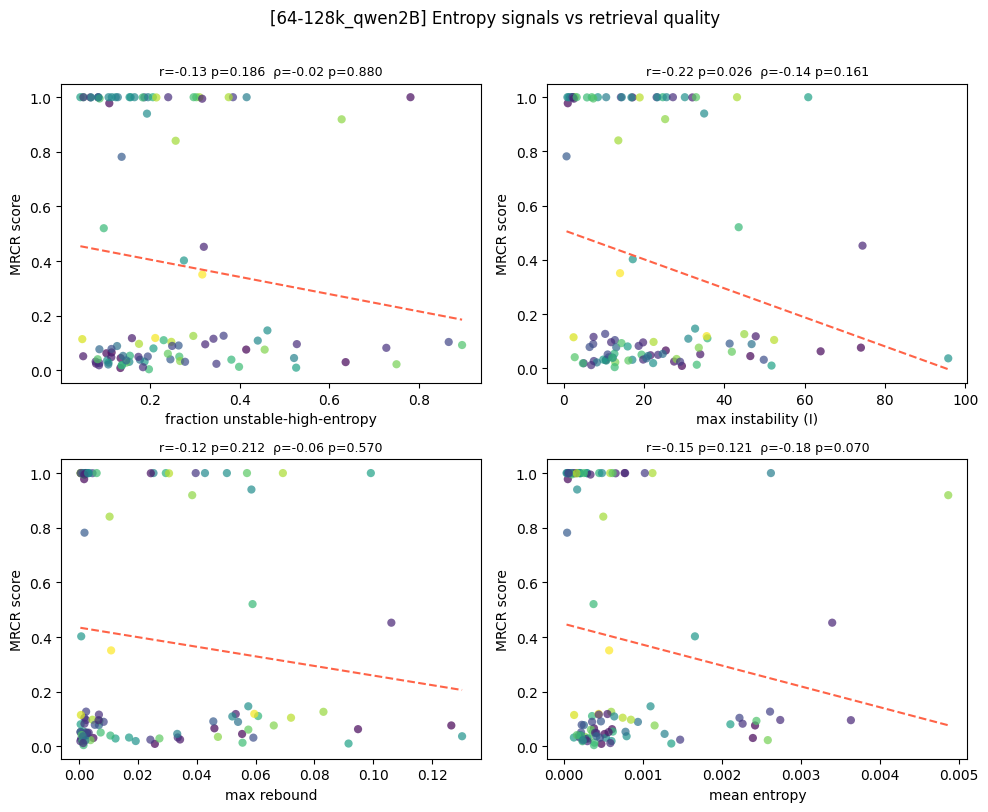

In [209]:
# ---- Boxplot: fraction_unstable_high_entropy by quality bin ----
# high_q = sdf[sdf["mrcr_score"] >= 0.8]["fraction_unstable_high_entropy"]
# low_q  = sdf[sdf["mrcr_score"] <= 0.2]["fraction_unstable_high_entropy"]
# print(f"high-quality (≥0.8): n={len(high_q)}  low-quality (≤0.2): n={len(low_q)}")

# fig, ax = plt.subplots(figsize=(4, 4.5))
# ax.boxplot([high_q, low_q], labels=["high\n(≥0.8)", "low\n(≤0.2)"],
#            patch_artist=True,
#            boxprops=dict(facecolor="steelblue", alpha=0.6),
#            medianprops=dict(color="black", linewidth=2))
# ax.set_ylabel("fraction unstable-high-entropy windows")
# ax.set_title(f"[{CTX_LABEL}] Quality bin vs instability")
# plt.tight_layout()
# plt.savefig(f"/c2/jenny/r3/MRCR_outputs/boxplot_instability_by_quality_{CTX_LABEL}.png", dpi=150)
# plt.show()

# ---- 2×2 scatter: four signals vs mrcr_score ----
signals = [
    ("fraction_unstable_high_entropy", "fraction unstable-high-entropy"),
    ("max_instability",                "max instability (I)"),
    ("max_rebound",                    "max rebound"),
    ("mean_entropy",                   "mean entropy"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (col, label) in zip(axes.flat, signals):
    x, y = sdf[col], sdf["mrcr_score"]
    ax.scatter(x, y, c=sdf["context_length"], cmap="viridis",
               alpha=0.7, edgecolors="none", s=35)
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m * xs + b, color="tomato", linewidth=1.5, linestyle="--")
    r, p     = pearsonr(x, y)
    rho, p_s = spearmanr(x, y)
    ax.set_xlabel(label)
    ax.set_ylabel("MRCR score")
    ax.set_title(f"r={r:.2f} p={p:.3f}  ρ={rho:.2f} p={p_s:.3f}", fontsize=9)

plt.suptitle(f"[{CTX_LABEL}] Entropy signals vs retrieval quality", y=1.01)
plt.tight_layout()
plt.savefig(f"/c2/jenny/r3/MRCR_outputs/signals_vs_score_2x2_{CTX_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

success: 36  failure: 66


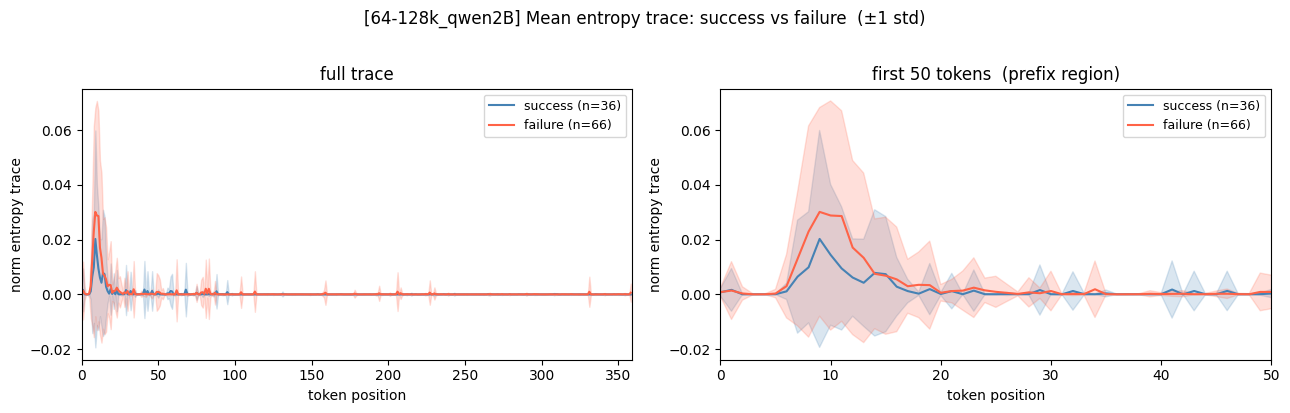

In [210]:
# ---- Average trace alignment: success vs failure ----
success_traces = [r[ENTROPY_KEY] for r in records if r["mrcr_score"] >= 0.5]
failure_traces = [r[ENTROPY_KEY] for r in records if r["mrcr_score"] <  0.5]
print(f"success: {len(success_traces)}  failure: {len(failure_traces)}")

def stack_traces(traces, min_coverage_frac=0.5):
    """Pad traces with NaN, drop positions covered by fewer than min_coverage_frac of samples."""
    max_len = max(len(t) for t in traces)
    arr = np.full((len(traces), max_len), np.nan)
    for i, t in enumerate(traces):
        arr[i, :len(t)] = t
    keep = np.sum(~np.isnan(arr), axis=0) >= len(traces) * min_coverage_frac
    return arr[:, keep]

S = stack_traces(success_traces)
F = stack_traces(failure_traces)

# Trim both to the same length for a fair x-axis
n_pos = min(S.shape[1], F.shape[1])
S, F = S[:, :n_pos], F[:, :n_pos]

xs = np.arange(n_pos)
s_mean, s_std = np.nanmean(S, axis=0), np.nanstd(S, axis=0)
f_mean, f_std = np.nanmean(F, axis=0), np.nanstd(F, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, xlim, subtitle in [
    (axes[0], (0, n_pos),  "full trace"),
    (axes[1], (0, 50),     "first 50 tokens  (prefix region)"),
]:
    ax.plot(xs, s_mean, color="steelblue", linewidth=1.5,
            label=f"success (n={len(success_traces)})")
    ax.fill_between(xs, s_mean - s_std, s_mean + s_std,
                    color="steelblue", alpha=0.2)
    ax.plot(xs, f_mean, color="tomato", linewidth=1.5,
            label=f"failure (n={len(failure_traces)})")
    ax.fill_between(xs, f_mean - f_std, f_mean + f_std,
                    color="tomato", alpha=0.2)
    ax.set_xlim(*xlim)
    ax.set_xlabel("token position")
    ax.set_ylabel(ENTROPY_KEY.replace("_", " "))
    ax.set_title(subtitle)
    ax.legend(fontsize=9)

fig.suptitle(f"[{CTX_LABEL}] Mean entropy trace: success vs failure  (±1 std)", y=1.02)
plt.tight_layout()
plt.savefig(f"/c2/jenny/r3/MRCR_outputs/trace_alignment_{CTX_LABEL}.png", dpi=150, bbox_inches="tight")
plt.show()

In [211]:
EARLY_WINDOW = 50   # token positions to treat as the retrieval-decision window

def early_window_features(rec, n=EARLY_WINDOW):
    ent    = np.array(rec[ENTROPY_KEY][:n],        dtype=np.float64)
    margin = np.array(rec["prob_margin_trace"][:n], dtype=np.float64)
    k = min(len(ent), len(margin))
    if k < 2:
        return {k: np.nan for k in
                ["peak_entropy_early", "max_margin_early",
                 "mean_margin_early", "entropy_margin_corr", "confused_score"]}
    ent, margin = ent[:k], margin[:k]
    corr = float(np.corrcoef(ent, margin)[0, 1])
    if not np.isfinite(corr):
        corr = 0.0
    peak_ent = float(ent.max())
    max_mar  = float(margin.max())
    return {
        "peak_entropy_early":  peak_ent,
        "max_margin_early":    max_mar,
        "mean_margin_early":   float(margin.mean()),
        # negative correlation = entropy dropped as margin rose = exploratory
        # near-zero / positive = entropy stayed high, no commitment = confused
        "entropy_margin_corr": corr,
        # high peak entropy + low max margin = confused
        "confused_score":      peak_ent / (max_mar + 1e-6),
    }

early_df = pd.DataFrame([early_window_features(r) for r in records])
sdf = pd.concat([sdf.reset_index(drop=True), early_df.reset_index(drop=True)], axis=1)

def spearman_safe(col):
    mask = sdf[col].notna()
    rho, p = spearmanr(sdf.loc[mask, col], sdf.loc[mask, "mrcr_score"])
    return round(rho, 3), round(p, 4)

all_signals = [
    "peak_entropy_early", "max_margin_early", "mean_margin_early",
    "entropy_margin_corr", "confused_score",
    "fraction_unstable_high_entropy", "max_rebound",
    "mean_instability", "max_instability", "mean_entropy",
]
corr_rows = [{"signal": c, "spearman_rho": spearman_safe(c)[0],
              "p_value": spearman_safe(c)[1]} for c in all_signals]
corr_df2 = (pd.DataFrame(corr_rows)
              .assign(abs_rho=lambda d: d["spearman_rho"].abs())
              .sort_values("abs_rho", ascending=False)
              .drop(columns="abs_rho")
              .reset_index(drop=True))
print(f"[{CTX_LABEL}]  early_window={EARLY_WINDOW}  — Spearman ρ vs mrcr_score\n")
print(corr_df2.to_string(index=False))

[64-128k_qwen2B]  early_window=50  — Spearman ρ vs mrcr_score

                        signal  spearman_rho  p_value
            peak_entropy_early        -0.525   0.0000
                confused_score        -0.525   0.0000
             mean_margin_early         0.389   0.0001
                  mean_entropy        -0.180   0.0703
               max_instability        -0.140   0.1613
              mean_instability        -0.109   0.2759
                   max_rebound        -0.057   0.5702
              max_margin_early         0.052   0.6020
           entropy_margin_corr        -0.042   0.6768
fraction_unstable_high_entropy        -0.015   0.8799


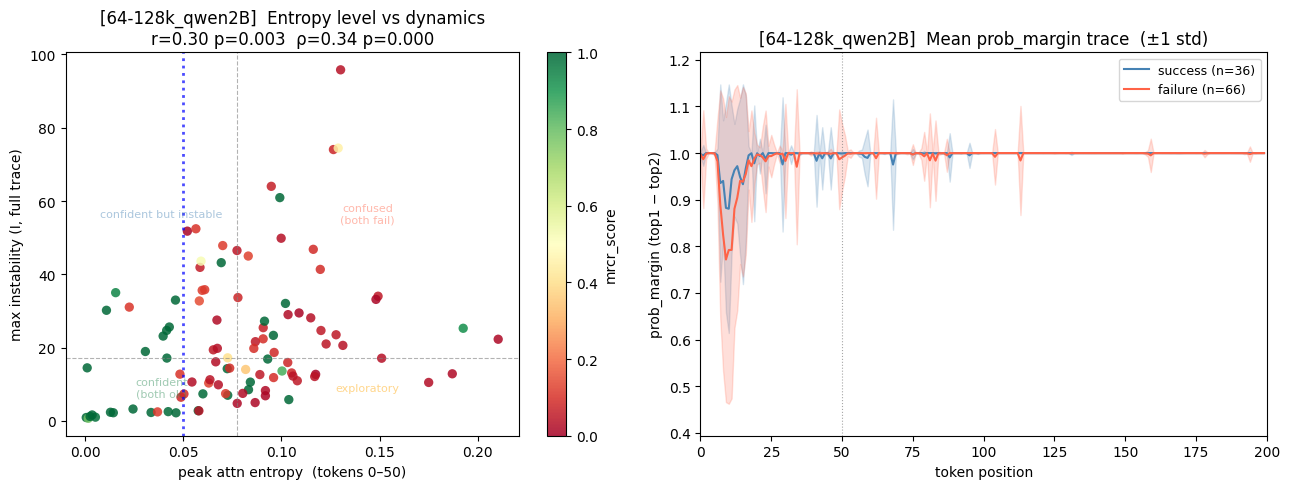

In [215]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ---- Left: entropy level vs instability scatter ----
# x = peak attention entropy in early window  (level signal)
# y = max_instability across full trace       (dynamics signal)
# Both correlate negatively with mrcr_score; 2D structure shows whether
# the two signals are redundant or complementary.
ax = axes[0]

x = sdf["peak_entropy_early"]
y = sdf["max_instability"]

sc = ax.scatter(x, y, c=sdf["mrcr_score"], cmap="RdYlGn", vmin=0, vmax=1,
                alpha=0.85, edgecolors="none", s=45)
plt.colorbar(sc, ax=ax, label="mrcr_score")

med_x = x.median()
med_y = y.median()
ax.axvline(med_x, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axhline(med_y, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
ax.axvline(0.05, color="blue", linewidth=2, linestyle=":", alpha=0.7)

x_lo, x_hi = x.min(), x.max()
y_lo, y_hi = y.min(), y.max()
kw = dict(fontsize=8, alpha=0.45, ha="center", va="center")
ax.text((x_lo  + med_x) / 2, (med_y + y_hi) / 2, "confident but instable", color="steelblue", **kw)
ax.text((med_x + x_hi)  / 2, (med_y + y_hi) / 2, "confused\n(both fail)",       color="tomato",    **kw)
ax.text((med_x + x_hi)  / 2, (y_lo  + med_y) / 2, "exploratory",      color="orange",    **kw)
ax.text((x_lo  + med_x) / 2, (y_lo  + med_y) / 2, "confident\n(both ok)",       color="seagreen",  **kw)

r,   p   = pearsonr(x, y)
rho, p_s = spearmanr(x, y)
ax.set_xlabel(f"peak attn entropy  (tokens 0–{EARLY_WINDOW})")
ax.set_ylabel("max instability (I, full trace)")
ax.set_title(f"[{CTX_LABEL}]  Entropy level vs dynamics\n"
             f"r={r:.2f} p={p:.3f}  ρ={rho:.2f} p={p_s:.3f}")

# ---- Right: mean prob_margin trace alignment ----
ax = axes[1]
success_margins = [r["prob_margin_trace"] for r in records if r["mrcr_score"] >= 0.5]
failure_margins = [r["prob_margin_trace"] for r in records if r["mrcr_score"] <  0.5]

_SM = stack_traces(success_margins)
_FM = stack_traces(failure_margins)
n_pos_m = min(_SM.shape[1], _FM.shape[1], 200)
SM_m = _SM[:, :n_pos_m]
FM_m = _FM[:, :n_pos_m]

sm_mean = np.nanmean(SM_m, axis=0)
sm_std  = np.nanstd(SM_m,  axis=0)
fm_mean = np.nanmean(FM_m, axis=0)
fm_std  = np.nanstd(FM_m,  axis=0)
xs_m = np.arange(n_pos_m)

ax.plot(xs_m, sm_mean, color="steelblue", linewidth=1.5,
        label=f"success (n={len(success_margins)})")
ax.fill_between(xs_m, sm_mean - sm_std, sm_mean + sm_std,
                color="steelblue", alpha=0.2)
ax.plot(xs_m, fm_mean, color="tomato", linewidth=1.5,
        label=f"failure (n={len(failure_margins)})")
ax.fill_between(xs_m, fm_mean - fm_std, fm_mean + fm_std,
                color="tomato", alpha=0.2)
ax.axvline(EARLY_WINDOW, color="gray", linewidth=0.8, linestyle=":", alpha=0.7)

all_vals = np.concatenate([sm_mean - sm_std, sm_mean + sm_std,
                            fm_mean - fm_std, fm_mean + fm_std])
finite = all_vals[np.isfinite(all_vals)]
if len(finite):
    pad = (finite.max() - finite.min()) * 0.1 or 0.01
    ax.set_ylim(finite.min() - pad, finite.max() + pad)

ax.set_xlim(0, n_pos_m)
ax.set_xlabel("token position")
ax.set_ylabel("prob_margin (top1 − top2)")
ax.set_title(f"[{CTX_LABEL}]  Mean prob_margin trace  (±1 std)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"/c2/jenny/r3/MRCR_outputs/entropy_vs_instability_{CTX_LABEL}.png",
            dpi=150, bbox_inches="tight")
plt.show()

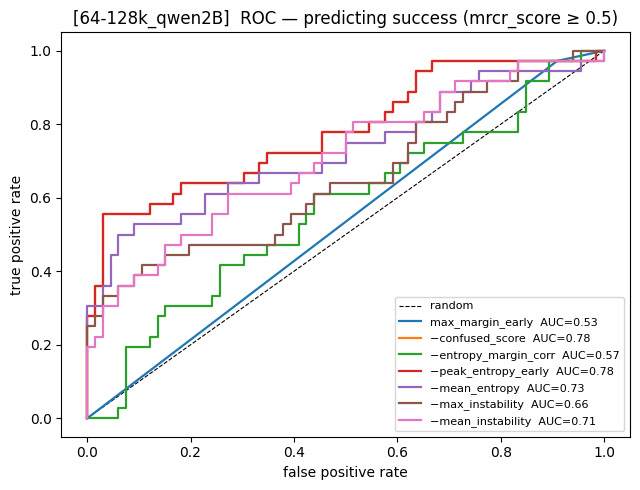

In [213]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = (sdf["mrcr_score"] >= 0.5).astype(int)   # 1 = success

# Each candidate: (label, scores_predicting_success)
# Negate signals where higher = worse, so higher always = predicted success
# NOTE: max_* signals require the full trace (offline only).
#       mean_* signals are computable as running means during decoding (real-time usable).
candidates = [
    ("max_margin_early",          sdf["max_margin_early"]),
    ("−confused_score",           -sdf["confused_score"]),
    ("−entropy_margin_corr",      -sdf["entropy_margin_corr"]),
    ("−peak_entropy_early",       -sdf["peak_entropy_early"]),
    ("−mean_entropy",             -sdf["mean_entropy"]),
    ("−max_instability",          -sdf["max_instability"]),   # offline only
    ("−mean_instability",         -sdf["mean_instability"]),  # real-time usable
]

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="random")

for name, scores in candidates:
    mask = scores.notna()
    fpr, tpr, _ = roc_curve(y_true[mask], scores[mask])
    auc = roc_auc_score(y_true[mask], scores[mask])
    ax.plot(fpr, tpr, linewidth=1.6, label=f"{name}  AUC={auc:.2f}")

ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title(f"[{CTX_LABEL}]  ROC — predicting success (mrcr_score ≥ 0.5)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.savefig(f"/c2/jenny/r3/MRCR_outputs/roc_{CTX_LABEL}.png", dpi=150)
plt.show()

In [214]:
# Are mean_entropy and mean_instability capturing overlapping or complementary information?
# If ρ < 0.6 → complementary, worth combining.  If ρ > 0.7 → largely redundant.
rho_ei, p_ei = spearmanr(sdf["mean_entropy"], sdf["mean_instability"])
print(f"[{CTX_LABEL}]  Spearman ρ(mean_entropy, mean_instability) = {rho_ei:.3f}  p={p_ei:.4f}")

# Also check correlation of their combined score with mrcr_score
from sklearn.preprocessing import StandardScaler
combined = (StandardScaler().fit_transform(sdf[["mean_entropy", "mean_instability"]])
            .mean(axis=1))
rho_comb, p_comb = spearmanr(combined, sdf["mrcr_score"])
print(f"combined score ρ vs mrcr_score = {rho_comb:.3f}  p={p_comb:.4f}")

# ROC for combined signal
from sklearn.metrics import roc_auc_score
auc_comb = roc_auc_score(y_true, -combined)
auc_ent  = roc_auc_score(y_true, -sdf["mean_entropy"])
auc_inst = roc_auc_score(y_true, -sdf["mean_instability"])
print(f"\nAUC  mean_entropy={auc_ent:.3f}  mean_instability={auc_inst:.3f}  combined={auc_comb:.3f}")

[64-128k_qwen2B]  Spearman ρ(mean_entropy, mean_instability) = 0.952  p=0.0000
combined score ρ vs mrcr_score = -0.134  p=0.1783

AUC  mean_entropy=0.728  mean_instability=0.707  combined=0.715
